In [39]:
# Libraries
import numpy as np
from tqdm import tqdm
from time import time
from PIL import Image
import datasetMng

import torch
from torch.optim import Adam
from torch.nn import CrossEntropyLoss, Conv2d, AvgPool2d, BatchNorm2d, Dropout2d, LeakyReLU, Linear, Module
from torch.utils.data import DataLoader

from torchvision.transforms import transforms
from torchvision.datasets import ImageFolder

In [41]:
# Build Model
class DistractionCNN(Module):
    def __init__(self):
        super(DistractionCNN, self).__init__()
        self.conv = Conv2d(in_channels=3, out_channels=8, kernel_size=(3,3), stride=1, padding=1)
        self.pool = AvgPool2d(kernel_size=(3,3), stride=1)
        self.relu = LeakyReLU()
        self.bn = BatchNorm2d(num_features=8)
        self.drop = Dropout2d(p=0.3)
        self.fc = Linear(in_features=8*126*126, out_features=5)
        
    def forward(self, X):
        output = self.conv(X)
        output = self.pool(output)
        output = self.relu(output)
        output = self.bn(output)
        output = self.drop(output)
#         print(output.shape)
        output = output.view(-1, 8*126*126)
        output = self.fc(output)
        return output

In [43]:
# Define Model and Migrate to GPU
model = DistractionCNN().to(device)
# Optimiser
optimiser = Adam(model.parameters(), lr=1e-4, weight_decay=0.0001)

# Loss Function
loss_fn = CrossEntropyLoss()

In [8]:
for epoch in range(25):
    start = time()
    train_acc = 0
    test_acc = 0

# Train
    model.train()
    with tqdm(train_loader, unit="batch") as tepoch:
        for xtrain, ytrain in tepoch:
            optimiser.zero_grad()
            xtrain = xtrain.to(device)
            train_prob = model(xtrain)
            train_prob = train_prob.cpu()
            train_loss = loss_fn(train_prob, ytrain)
            train_loss.backward()
            optimiser.step()
            # END TRAIN
            train_pred = torch.max(train_prob, 1).indices
            train_acc += int(torch.sum(train_pred == ytrain))
            
        train_epoch_accuracy = train_acc / len_train

# Evaluate
    model.eval()
    with torch.no_grad():
        for xtest, ytest in test_loader:
            xtest = xtest.to(device)
            test_prob = model(xtest)
            test_prob = test_prob.cpu()
            test_loss = loss_fn(test_prob, ytest)
            test_pred = torch.max(test_prob, 1).indices
            test_acc += int(torch.sum(test_pred == ytest))
        
        test_epoch_accuracy = test_acc / len_test
    
    end = time()
    
    diff = end - start
    
    print(f"Epoch: {epoch+1}, Time: {diff}\nTr_loss: {train_loss}, Test_loss: {test_loss}\n,Tr_acc:{train_epoch_accuracy}, Test_acc: {test_epoch_accuracy}")

100%|██████████| 505/505 [02:40<00:00,  3.14batch/s]


Epoch: 1, Time: 180.58811616897583
Tr_loss: 1.6902823448181152, Test_loss: 1.4734036922454834
,Tr_acc:0.5112211221122113, Test_acc: 0.6439888164026095


100%|██████████| 505/505 [01:33<00:00,  5.42batch/s]


Epoch: 2, Time: 103.51596856117249
Tr_loss: 0.7893157601356506, Test_loss: 0.6459027528762817
,Tr_acc:0.6485808580858086, Test_acc: 0.6808014911463187


100%|██████████| 505/505 [01:32<00:00,  5.43batch/s]


...

Epoch: 23, Time: 104.74444651603699
Tr_loss: 0.051443759351968765, Test_loss: 0.029442625120282173
,Tr_acc:0.8812541254125412, Test_acc: 0.9212488350419384


100%|██████████| 505/505 [01:35<00:00,  5.28batch/s]


Epoch: 24, Time: 106.06121110916138
Tr_loss: 0.12711817026138306, Test_loss: 0.19025537371635437
,Tr_acc:0.8909570957095709, Test_acc: 0.9394221808014911


100%|██████████| 505/505 [01:34<00:00,  5.35batch/s]


Epoch: 25, Time: 104.69824385643005
Tr_loss: 0.27394452691078186, Test_loss: 0.40047696232795715
,Tr_acc:0.8875907590759076, Test_acc: 0.9226467847157502


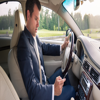

Model Pred: 0
Interpretation: Other activities


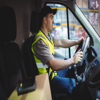

Model Pred: 2
Interpretation: Talking phone


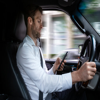

Model Pred: 3
Interpretation: Texting phone


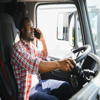

Model Pred: 0
Interpretation: Other activities


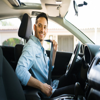

Model Pred: 1
Interpretation: Safe driving


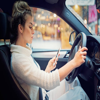

Model Pred: 1
Interpretation: Safe driving


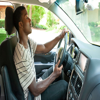

Model Pred: 2
Interpretation: Talking phone


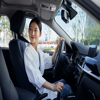

Model Pred: 2
Interpretation: Talking phone


In [22]:
# Image Samples
custom_images_path = "C:/Users/lucrezia.rettori/Desktop/Distraction_detection/test imgs/"
sample_1 = custom_images_path + "tp3.jpg"
sample_2 = custom_images_path + "sd1.jpg"
sample_3 = custom_images_path + "tp1.jpg"
sample_4 = custom_images_path + "ta2.jpg"
sample_5 = custom_images_path + "oa1.jpg"
sample_6 = custom_images_path + "tp2.jpg"
sample_7 = custom_images_path + "sd2.jpg"
sample_8 = custom_images_path + "t1.jpg"

sample_list = [sample_1,sample_2,sample_3,sample_4,sample_5,sample_6,sample_7,sample_8]
# Model Performance
for img_path in sample_list:
    img = Image.open(img_path)
    display(img.resize((100, 100)))
    img_tensor = tfm(img)
    img_tensor = img_tensor[np.newaxis, :]
    img_tensor = img_tensor.to(device)
    prob = model(img_tensor)
    pred = torch.max(prob, 1).indices
    pred = pred.item()
    if pred == 0:
        print(f"Model Pred: {pred}\nInterpretation: Other activities")
    elif pred == 1:
        print(f"Model Pred: {pred}\nInterpretation: Safe driving")
    elif pred == 2:
        print(f"Model Pred: {pred}\nInterpretation: Talking phone")
    elif pred == 3:
        print(f"Model Pred: {pred}\nInterpretation: Texting phone")
    else:
        print(f"Model Pred: {pred}\nInterpretation: Turning")
        
    print("===============================================================")